## Baseline-модель

Задача: регрессия

Таргет-метрика: `success_proxy_score`

Рассчитывается по формуле: `success_proxy_score = 0.65 * rating_norm + 0.35 * reviews_log_norm`

Где:

- `rating_norm = (Рейтинг - 1) / 4`;
- `reviews_log_norm = log1p(Оценок) / log1p(max(Оценок))`.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path("../data/processed/products_processed.csv")

In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1454, 43)


,Артикул,success_proxy_score,Бренд,Название,Категория,Спец. цена,Цена,Старая цена,Скидка,Цвет,...,special_price_log1p,old_price_log1p,discount_ratio_calc,price_to_old_price_ratio,images_count_log1p,has_images,many_images,brand_frequency,seller_frequency,category_frequency
0,144542463,0.905121,X-Plode,Летние кеды тканевые дышащие,Обувь / Кеды,1461.0,1491,3888.0,61.0,"серый, белый",...,7.287561,8.265907,0.616512,0.383488,2.397895,1,1,0.027709,0.027709,0.99359
1,204459429,0.848275,Strobbs,Кеды мужские весенние,Обувь / Кеды,5639.0,5755,11990.0,52.0,серый,...,8.637639,9.391912,0.520017,0.479983,2.397895,1,1,0.000620,0.000620,0.99359
2,65828833,0.950545,X-Plode,Джинсовые летние кеды тканевые,Обувь / Кеды,1206.0,1231,3210.0,61.0,"синий, белый",...,7.095893,8.074338,0.616511,0.383489,2.397895,1,1,0.027709,0.027709,0.99359
3,225083731,0.873602,Vans,Кеды низкие повседневные,Обувь / Кеды,1854.0,1892,2500.0,24.0,"черный, белый",...,7.525640,7.824446,0.243200,0.756800,1.609438,1,0,0.001034,0.000207,0.99359
4,549184075,0.836232,X-Plode,Тканевые кеды летние дышащие,Обувь / Кеды,2034.0,2076,5414.0,61.0,красный,...,7.618251,8.596928,0.616550,0.383450,2.397895,1,1,0.027709,0.027709,0.99359


## 1. Признаки

In [7]:
target_col = "success_proxy_score"
id_columns = ["Артикул"]

text_features = ["Название", "Описание", "Состав"]

excluded_columns = set([target_col] + id_columns + text_features)

numeric_features = [
    col for col in df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(df[col])
]
categorical_features = [
    col for col in df.columns
    if col not in excluded_columns and not pd.api.types.is_numeric_dtype(df[col])
]
text_features_present = [c for c in text_features if c in df.columns]

print("Числовые признаки:", len(numeric_features))
print("Категориальные признаки:", len(categorical_features))
print("Текстовые признаки (не используем в baseline):", text_features_present)

Числовые признаки: 26
Категориальные признаки: 12
Текстовые признаки (не используем в baseline): ['Название', 'Описание', 'Состав']


Рассмотрим распределение таргет-метрики.

,success_proxy_score
count,1454.000000
mean,0.748938
std,0.065614
min,0.447288
25%,0.701785
50%,0.748207
75%,0.795707
max,0.954354


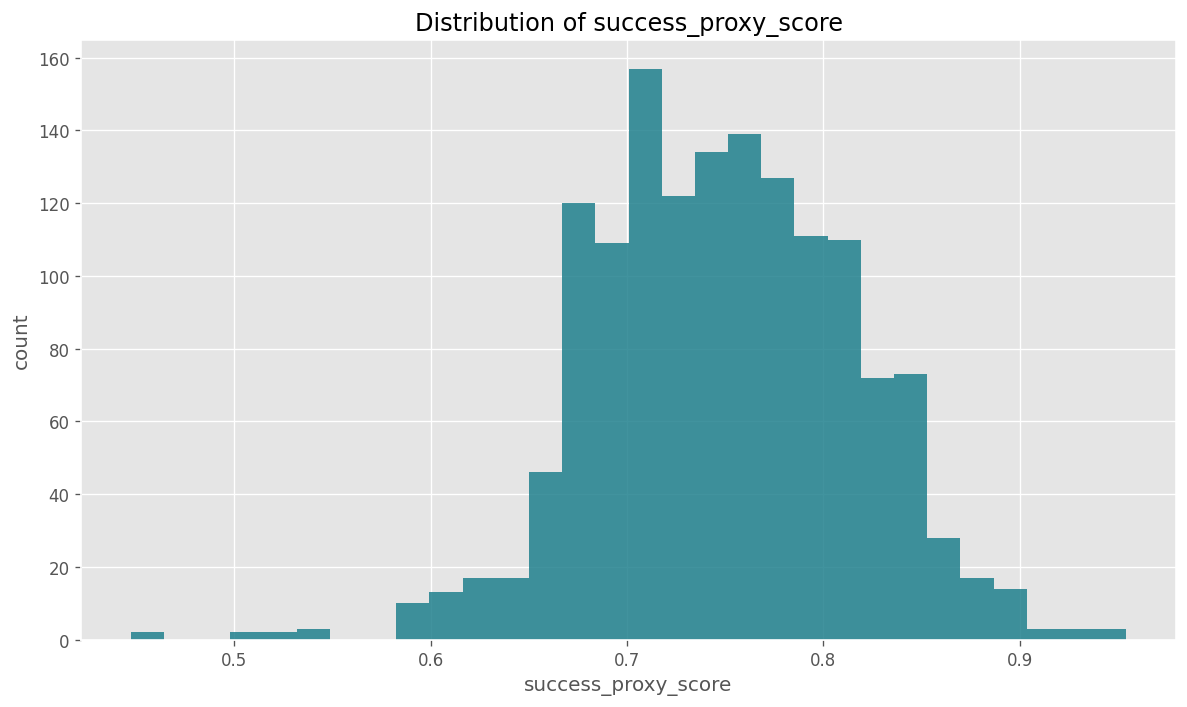

In [8]:
target_stats = df[target_col].describe().to_frame("success_proxy_score")
display(target_stats)

ax = df[target_col].hist(bins=30, color="#20808D", alpha=0.85)
ax.set_title("Distribution of success_proxy_score")
ax.set_xlabel("success_proxy_score")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

Теперь посмотрим признаки, которые будем использовать для обучения baseline-моделей.

In [9]:
features_for_baseline = numeric_features + categorical_features

X = df[features_for_baseline].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features before one-hot:", len(features_for_baseline))

display(pd.DataFrame({
    "feature": features_for_baseline,
    "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
}).head(50))

X shape: (1454, 38)
y shape: (1454,)
Number of features before one-hot: 38


,feature,type
0,Спец. цена,numeric
1,Цена,numeric
2,Старая цена,numeric
3,Скидка,numeric
4,Кол-во картинок,numeric
5,name_len,numeric
6,name_word_count,numeric
7,description_len,numeric
8,description_word_count,numeric
9,description_missing,numeric


## 2. Train/Validation/Test
Делим данные в пропорции 70/15/15 из-за небольшого датасета. Так как наша задача - регрессия, то распределения по классу нет, но чтобы таргет-метрика во всех выборках была примерно одинаково распределена, создадим временные бины для таргета и используем их для равномерного разбиения.

In [10]:
target_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X,
    y,
    target_bins,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=target_bins,
)

temp_bins = pd.qcut(y_temp, q=5, labels=False, duplicates="drop")

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_bins,
)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(X_train), "target_mean": y_train.mean(), "target_std": y_train.std()},
    {"split": "validation", "rows": len(X_val), "target_mean": y_val.mean(), "target_std": y_val.std()},
    {"split": "test", "rows": len(X_test), "target_mean": y_test.mean(), "target_std": y_test.std()},
])

split_summary

,split,rows,target_mean,target_std
0,train,1017,0.749362,0.065992
1,validation,218,0.748309,0.065101
2,test,219,0.747593,0.064627


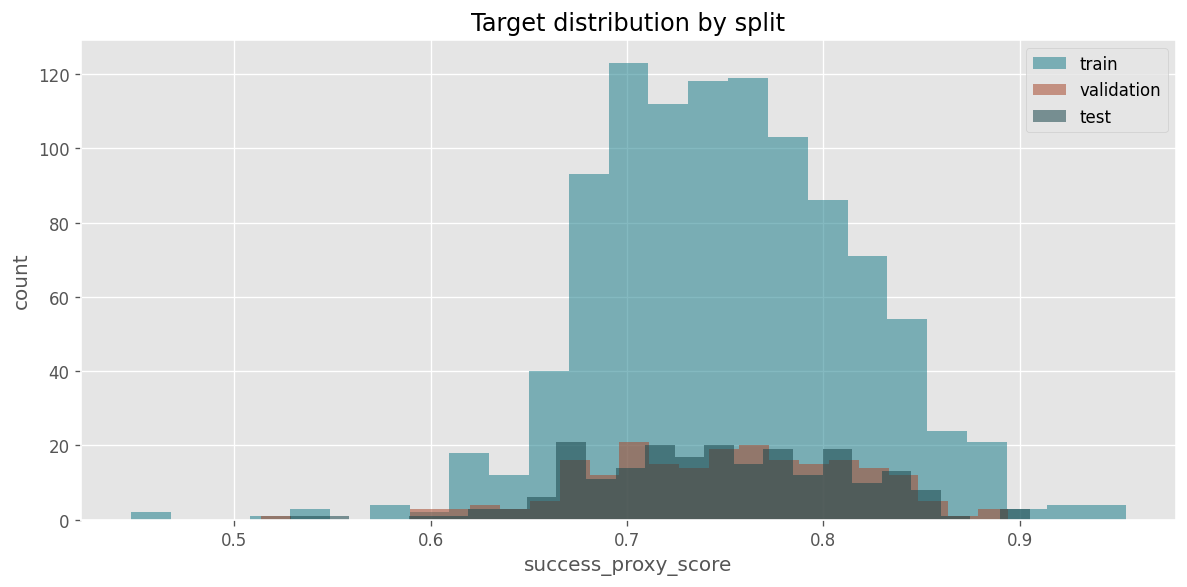

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_train, bins=25, alpha=0.55, label="train", color="#20808D")
ax.hist(y_val, bins=25, alpha=0.55, label="validation", color="#A84B2F")
ax.hist(y_test, bins=25, alpha=0.55, label="test", color="#1B474D")
ax.set_title("Target distribution by split")
ax.set_xlabel("success_proxy_score")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Предобработка для моделей

Используем `ColumnTransformer`:

Для числовых признаков: пропуски заполняем медианой, масштабируем через `StandartScaler`.

Для категориальных признаков: пропуски заполняем значением `__MISSING__`, кодируем через `OneHotEncoder`. 

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

## 4. Метрики

Будем использовать стандартные метрики качества для регрессионых задач:

- MAE: средняя абсолютная ошибка. Будем считать её основной метрикой качества.
- RMSE: сильнее штрафует модель за большие ошибки.
- $R^2$: показывает долю объяснённой дисперсии.
- Spearman: показывает, насколько хорошо модель расставляет карточки по успешности.

In [13]:
def regression_metrics(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    spearman = spearmanr(y_true, y_pred).correlation
    if pd.isna(spearman):
        spearman = None
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Spearman": spearman,
    }


def evaluate_model(name: str, model, X_train, y_train, X_val, y_val) -> tuple[Pipeline, dict]:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    val_pred = pipe.predict(X_val)
    metrics = regression_metrics(y_val, val_pred)
    metrics["model"] = name
    return pipe, metrics

## 5. Обучение моделей
Сравниваем простые модели: DummyRegressor, Ridge, KNN, RandomForest. DummyRegressor всегда предсказывает среднее значение таргет-метрики, поэтому его мы используем просто для оценки валидности признаков для обучения.

In [14]:
models = {
    "DummyMean": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "KNN_5": KNeighborsRegressor(n_neighbors=5, weights="distance"),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

trained_models = {}
validation_rows = []

for name, model in models.items():
    pipe, metrics = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    trained_models[name] = pipe
    validation_rows.append(metrics)

validation_results = pd.DataFrame(validation_rows).sort_values("MAE")
validation_results

C:\Users\yashi\AppData\Local\Temp\ipykernel_20304\134725574.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred).correlation


,MAE,RMSE,R2,Spearman,model
3,0.038854,0.051894,0.361635,0.677289,RandomForest
2,0.039860,0.053926,0.310682,0.605368,KNN_5
1,0.041180,0.053814,0.313523,0.604748,Ridge
0,0.052894,0.064960,-0.000263,NaN,DummyMean


Проверим обученные модели на выборке validation.

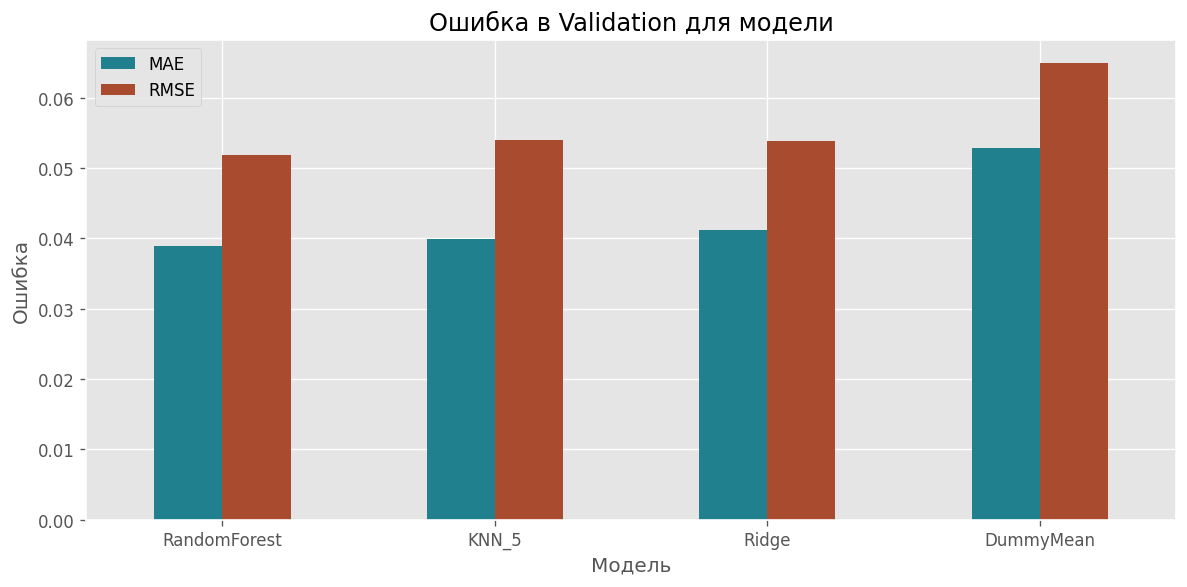

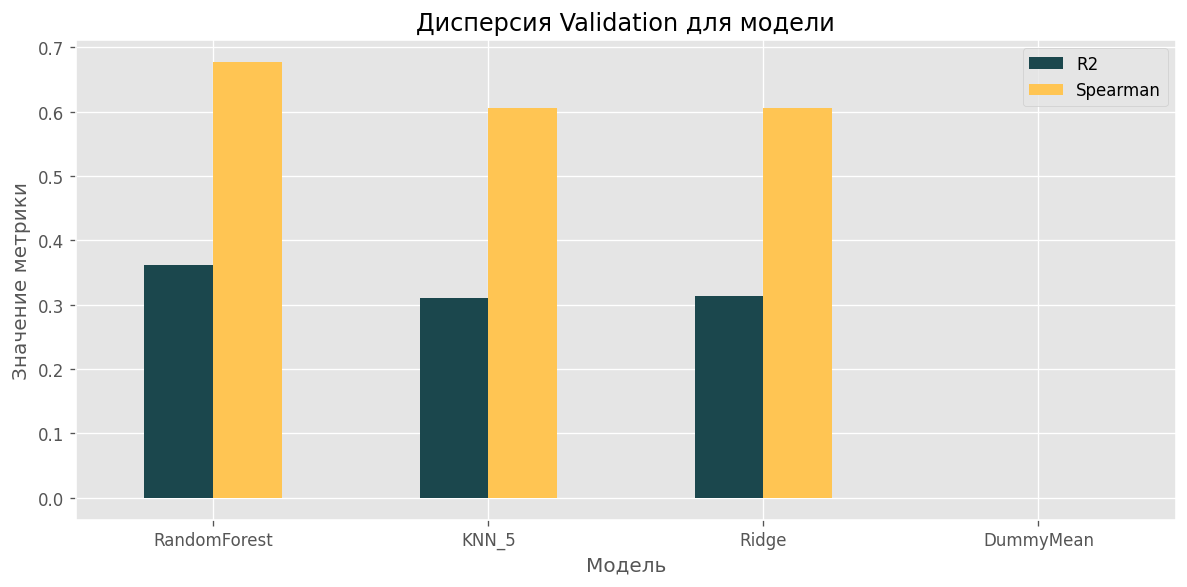

In [19]:
ax = validation_results.set_index("model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#20808D", "#A84B2F"],
)
ax.set_title("Ошибка в Validation для модели")
ax.set_ylabel("Ошибка")
ax.set_xlabel("Модель")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ax = validation_results.set_index("model")[["R2", "Spearman"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#1B474D", "#FFC553"],
)
ax.set_title("Дисперсия Validation для модели")
ax.set_ylabel("Значение метрики")
ax.set_xlabel("Модель")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Оценка на тестовой выборке

По результатам validation лучшая модель - это RandomForest. Проверим её на тестовой выборке.

In [20]:
best_model_name = validation_results.iloc[0]["model"]
best_model = models[best_model_name]

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model),
])

best_pipe.fit(X_train_val, y_train_val)
test_pred = best_pipe.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)

print("Лучшая модель:", best_model_name)
pd.DataFrame([{**{"модель": best_model_name}, **test_metrics}])

Лучшая модель: RandomForest


,модель,MAE,RMSE,R2,Spearman
0,RandomForest,0.040292,0.050404,0.388936,0.648396


,count,mean,std,min,25%,50%,75%,max
y_true,219.0,0.747593,0.064627,0.528538,0.701785,0.747382,0.797646,0.905121
y_pred,219.0,0.747689,0.034369,0.670969,0.723147,0.748030,0.772488,0.847783
error,219.0,0.000096,0.050519,-0.158095,-0.035934,-0.003699,0.032278,0.184479
abs_error,219.0,0.040292,0.030353,0.000019,0.017396,0.034085,0.057133,0.184479


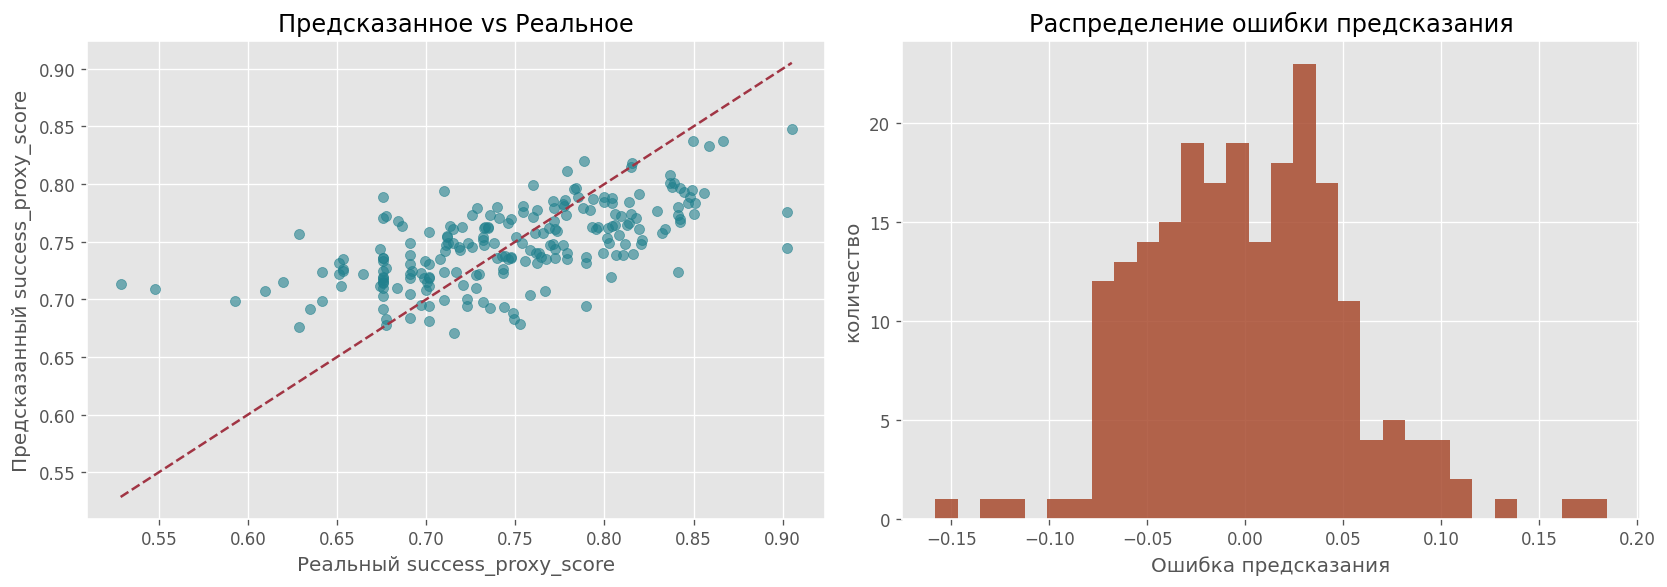

In [22]:
predictions_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred,
    "error": test_pred - y_test,
    "abs_error": np.abs(test_pred - y_test),
})

display(predictions_df.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(predictions_df["y_true"], predictions_df["y_pred"], alpha=0.6, color="#20808D")
min_val = min(predictions_df["y_true"].min(), predictions_df["y_pred"].min())
max_val = max(predictions_df["y_true"].max(), predictions_df["y_pred"].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="#A13544", linestyle="--")
axes[0].set_title("Предсказанное vs Реальное")
axes[0].set_xlabel("Реальный success_proxy_score")
axes[0].set_ylabel("Предсказанный success_proxy_score")

axes[1].hist(predictions_df["error"], bins=30, color="#A84B2F", alpha=0.85)
axes[1].set_title("Распределение ошибки предсказания")
axes[1].set_xlabel("Ошибка предсказания")
axes[1].set_ylabel("количество")

plt.tight_layout()
plt.show()

## 7. Вывод
Базовая модель находит общую зависимость и показывает хорошие результаты обучения, однако диапазон предсказаний стремится усреднить значение таргет-метрики, то есть типичные карточки baseline предсказывает хорошо, а успешные/слабые карточки хуже.